In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/dm-dataset/val/PNEUMONIA/person1947_bacteria_4876.jpeg
/kaggle/input/dm-dataset/val/PNEUMONIA/person1946_bacteria_4875.jpeg
/kaggle/input/dm-dataset/val/PNEUMONIA/person1952_bacteria_4883.jpeg
/kaggle/input/dm-dataset/val/PNEUMONIA/person1954_bacteria_4886.jpeg
/kaggle/input/dm-dataset/val/PNEUMONIA/person1951_bacteria_4882.jpeg
/kaggle/input/dm-dataset/val/PNEUMONIA/person1946_bacteria_4874.jpeg
/kaggle/input/dm-dataset/val/PNEUMONIA/person1949_bacteria_4880.jpeg
/kaggle/input/dm-dataset/val/PNEUMONIA/person1950_bacteria_4881.jpeg
/kaggle/input/dm-dataset/val/NORMAL/NORMAL2-IM-1431-0001.jpeg
/kaggle/input/dm-dataset/val/NORMAL/NORMAL2-IM-1440-0001.jpeg
/kaggle/input/dm-dataset/val/NORMAL/NORMAL2-IM-1442-0001.jpeg
/kaggle/input/dm-dataset/val/NORMAL/NORMAL2-IM-1427-0001.jpeg
/kaggle/input/dm-dataset/val/NORMAL/NORMAL2-IM-1430-0001.jpeg
/kaggle/input/dm-dataset/val/NORMAL/NORMAL2-IM-1436-0001.jpeg
/kaggle/input/dm-dataset/val/NORMAL/NORMAL2-IM-1438-0001.jpeg
/kaggle/input/

In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
import os
import seaborn as sns
%matplotlib inline
import glob
import PIL
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.model_selection import GridSearchCV
import tensorflow as tf
from tensorflow.keras import regularizers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (BatchNormalization, Conv2D, MaxPooling2D, Activation, Flatten, Dropout, Dense)
from tensorflow.keras import backend as K

2025-05-23 21:45:17.198341: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1748036717.443344      35 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1748036717.512448      35 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
import os
from glob import glob

In [4]:
import os
from glob import glob
train_dir = "/kaggle/input/dm-dataset/train"
test_dir = "/kaggle/input/dm-dataset/test"
val_dir = "/kaggle/input/dm-dataset/val"

print("Number of images in Train is {}".format(len(glob(train_dir + "/*/*"))))
print("Number of images in Test is {}".format(len(glob(test_dir + "/*/*"))))
print("Number of images in Validation is {}".format(len(glob(val_dir + "/*/*"))))

normal = os.listdir(train_dir + "/NORMAL")
covid = os.listdir(train_dir + "/COVID19")
pneumonia = os.listdir(train_dir + "/PNEUMONIA")
tuberculosis = os.listdir(train_dir + "/TUBERCULOSIS") 

print("Number of images in NORMAL category is {}".format(len(normal)))
print("Number of images in COVID19 category is {}".format(len(covid)))
print("Number of images in PNEUMONIA category is {}".format(len(pneumonia)))
print("Number of images in TUBERCULOSIS category is {}".format(len(tuberculosis)))



Number of images in Train is 6326
Number of images in Test is 771
Number of images in Validation is 38


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/dm-dataset/train/TUBERCULOSIS'

In [5]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator
data_generator_1 = ImageDataGenerator(
                            rescale=1./255,
                            rotation_range=5,
                            width_shift_range=0.05,
                            height_shift_range=0.05,
                            shear_range=0.05,
                            zoom_range=0.05,
                            brightness_range = [0.95,1.05],
                            horizontal_flip=False,
                            vertical_flip=False,
                            fill_mode='nearest'                                   
                        )

print('Data Augmentation 1 was created')

data_generator_2 = ImageDataGenerator(
                            rescale=1./255,
                            rotation_range=10,
                            width_shift_range=0.1,
                            height_shift_range=0.1,
                            shear_range=0.1,
                            zoom_range=0.1,
                            brightness_range = [0.9,1.1],
                            horizontal_flip=False,
                            vertical_flip=False,
                            fill_mode='nearest'                                   
                        )
print('Data Augmentation 2 was created')

data_generator_3 = ImageDataGenerator (rescale=1./255)

Data Augmentation 1 was created
Data Augmentation 2 was created


In [6]:
BATCH_SIZE = 48

image_height =64
image_width = 64
train_generator1 = data_generator_1.flow_from_directory(
    directory = "/kaggle/input/dm-dataset/train", # images data path / folder in which images are there
    color_mode = "rgb",
    target_size = (image_height, image_width), # image height , image width
    class_mode = "categorical",
    batch_size = BATCH_SIZE,
    shuffle = True,
    seed = 42)

print('Data Augmentation 1 was used to generate train data set\n')
test_generator = data_generator_3.flow_from_directory(
    directory = "/kaggle/input/dm-dataset/test", # images data path / folder in which images are there
    color_mode = "rgb",
    target_size = (image_height, image_width), # image height , image width
    class_mode = "categorical",
    batch_size = BATCH_SIZE,
    shuffle = True,
    seed = 42)
Val_generator = data_generator_3.flow_from_directory(
    directory = "//kaggle/input/dm-dataset/val", # images data path / folder in which images are there
    color_mode = "rgb",
    target_size = (image_height, image_width), # image height , image width
    class_mode = "categorical",
    batch_size = BATCH_SIZE,
    shuffle = True,
    seed = 42)

Found 6326 images belonging to 4 classes.
Data Augmentation 1 was used to generate train data set

Found 771 images belonging to 4 classes.
Found 38 images belonging to 4 classes.


In [7]:
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, concatenate, Flatten, Dense, BatchNormalization, Dropout
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.callbacks import ReduceLROnPlateau

# Step 1: Define image shape
img_shape = (64, 64, 3)  # Example: 224x224 RGB images

# Step 2: Grouped convolution block
def grouped_conv_block(x, filters, groups, kernel_size):
    channels_per_group = filters // groups
    groups_list = []
    for i in range(groups):
        group = Conv2D(channels_per_group, kernel_size, padding='same', activation='relu')(x)
        groups_list.append(group)
    return concatenate(groups_list)

# Step 3: Build the model
inputs = Input(shape=img_shape)
x = Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu')(inputs)
x = Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu')(x)
x = MaxPooling2D(pool_size=(2, 2))(x)

x = grouped_conv_block(x, filters=128, groups=16, kernel_size=(3, 3))
x = MaxPooling2D(pool_size=(2, 2))(x)

x = grouped_conv_block(x, filters=256, groups=16, kernel_size=(3, 3))
x = MaxPooling2D(pool_size=(2, 2))(x)

x = grouped_conv_block(x, filters=512, groups=16, kernel_size=(3, 3))
x = MaxPooling2D(pool_size=(2, 2))(x)

x = grouped_conv_block(x, filters=512, groups=16, kernel_size=(3, 3))
x = MaxPooling2D(pool_size=(2, 2))(x)

x = Flatten()(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.5)(x)
x = Dense(64, activation='relu')(x)
outputs = Dense(4, activation='softmax')(x)

# Step 4: Compile the model
model = Model(inputs=inputs, outputs=outputs)
model.compile(optimizer=Adamax(learning_rate=0.001), loss='categorical_crossentropy', metrics=['accuracy'])

# Step 5: View the model
model.summary()


2025-05-23 21:46:03.974202: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)              ┃ Output Shape           ┃        Param # ┃ Connected to           ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)  │ (None, 64, 64, 3)      │              0 │ -                      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d (Conv2D)           │ (None, 64, 64, 64)     │          1,792 │ input_layer[0][0]      │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_1 (Conv2D)         │ (None, 64, 64, 64)     │         36,928 │ conv2d[0][0]           │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ max_pooling2d             │ (None, 32, 32, 64)     │              0 │ conv2d_1[0][0]         │
│ (MaxPooling2D)            │                        │                │                        │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_2 (Conv2D)         │ (None, 32, 32, 8)      │          4,616 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_3 (Conv2D)         │ (None, 32, 32, 8)      │          4,616 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_4 (Conv2D)         │ (None, 32, 32, 8)      │          4,616 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_5 (Conv2D)         │ (None, 32, 32, 8)      │          4,616 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_6 (Conv2D)         │ (None, 32, 32, 8)      │          4,616 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_7 (Conv2D)         │ (None, 32, 32, 8)      │          4,616 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_8 (Conv2D)         │ (None, 32, 32, 8)      │          4,616 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_9 (Conv2D)         │ (None, 32, 32, 8)      │          4,616 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_10 (Conv2D)        │ (None, 32, 32, 8)      │          4,616 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_11 (Conv2D)        │ (None, 32, 32, 8)      │          4,616 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_12 (Conv2D)        │ (None, 32, 32, 8)      │          4,616 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_13 (Conv2D)        │ (None, 32, 32, 8)      │          4,616 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_14 (Conv2D)        │ (None, 32, 32, 8)      │          4,616 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_15 (Conv2D)        │ (None, 32, 32, 8)      │          4,616 │ max_pooling2d[0][0]    │
├───────────────────────────┼────────────────────────┼────────────────┼────────────────────────┤
│ conv2d_16 (Conv2D)        │ (None, 32, 32, 8)      │          4,616 │ max_pooling2d[0][0]    │
├──────────────────────

 Total params: 4,488,964 (17.12 MB)

 Trainable params: 4,488,964 (17.12 MB)

 Non-trainable params: 0 (0.00 B)

In [8]:
resnext=model.fit(
    train_generator1,
    steps_per_epoch=len(train_generator1),
    epochs=20,
    validation_data=test_generator,
    validation_steps=len(test_generator)
)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 422s 3s/step - accuracy: 0.5937 - loss: 1.0248 - val_accuracy: 0.8003 - val_loss: 0.5848
Epoch 2/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 377s 3s/step - accuracy: 0.8179 - loss: 0.4687 - val_accuracy: 0.8560 - val_loss: 0.3979
Epoch 3/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 384s 3s/step - accuracy: 0.8796 - loss: 0.3159 - val_accuracy: 0.7730 - val_loss: 0.7416
Epoch 4/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 377s 3s/step - accuracy: 0.9206 - loss: 0.2311 - val_accuracy: 0.8677 - val_loss: 0.3987
Epoch 5/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 380s 3s/step - accuracy: 0.9344 - loss: 0.1985 - val_accuracy: 0.8197 - val_loss: 0.5328
Epoch 6/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 379s 3s/step - accuracy: 0.9435 - loss: 0.1612 - val_accuracy: 0.7756 - val_loss: 0.9786
Epoch 7/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 374s 3s/step - accuracy: 0.9466 - loss: 0.1595 - val_accuracy: 0.7588 - val_loss: 1.0055
Epoch 8/20
132/132 ━━━━━━━━━━━━━━━━━━━━ 376s 3s/step - accuracy: 0.9497 - loss: 0.1417 - val_accu

In [11]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Generate predictions
predictions = model.predict(test_generator)

# Convert predictions to class labels
predicted_classes = np.argmax(predictions, axis=1)

# Get true labels
true_classes = test_generator.classes

# Generate and print classification report
report = classification_report(true_classes, predicted_classes, target_names=test_generator.class_indices)
print("Classification Report:\n", report)

# Generate and plot confusion matrix
conf_matrix = confusion_matrix(true_classes, predicted_classes)
print("Confusion Matrix:\n", conf_matrix)

17/17 ━━━━━━━━━━━━━━━━━━━━ 15s 875ms/step
Classification Report:
                precision    recall  f1-score   support

      COVID19       0.13      0.11      0.12       106
       NORMAL       0.34      0.22      0.27       234
    PNEUMONIA       0.51      0.63      0.56       390
TURBERCULOSIS       0.02      0.02      0.02        41

     accuracy                           0.40       771
    macro avg       0.25      0.25      0.24       771
 weighted avg       0.38      0.40      0.38       771

Confusion Matrix:
 [[ 12  19  68   7]
 [ 26  51 143  14]
 [ 49  75 245  21]
 [  8   4  28   1]]


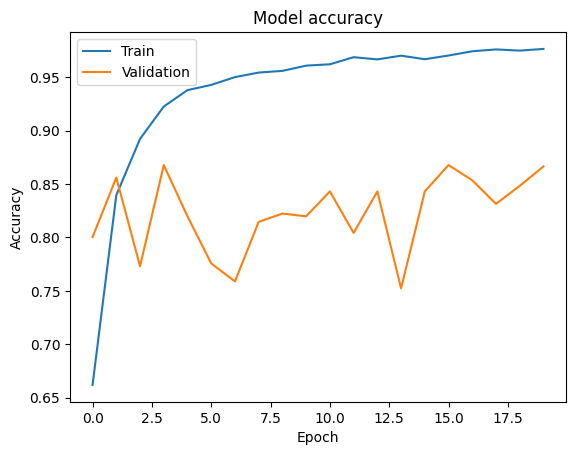

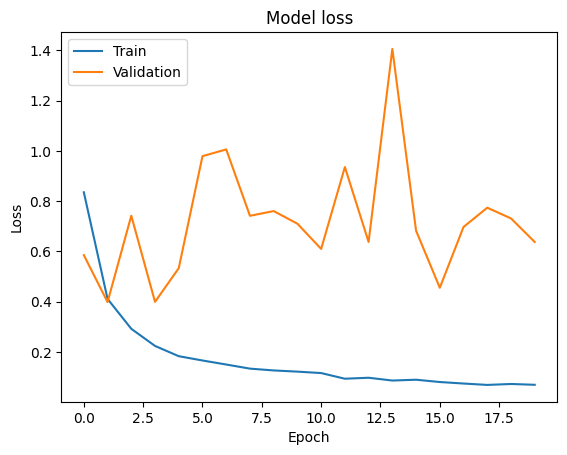

In [12]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.plot(resnext.history['accuracy'])
plt.plot(resnext.history['val_accuracy'])
plt.title('Model accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

# Plot training & validation loss values
plt.plot(resnext.history['loss'])
plt.plot(resnext.history['val_loss'])
plt.title('Model loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.show()

